In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, json, os, pickle
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

for r in ['punkt','punkt_tab','stopwords']:
    try: nltk.data.find(f'tokenizers/{r}' if 'punkt' in r else f'corpora/{r}')
    except: nltk.download(r, quiet=True)

severity_names = {1:'No Explicit Reproach', 2:'Disapproval', 3:'Accusation', 4:'Blame'}
print('Library berhasil dimuat.')


Library berhasil dimuat.


# **1. DATA PREPARATION**

In [ ]:
data = pd.read_csv('../dataset/data_pesan_telekomunikasi.csv')

data = data[data['severity'] > 0].reset_index(drop=True)
data.rename(columns={'text': 'message'}, inplace=True)

print(f'Total data keluhan: {len(data):,}')
print(data['severity'].value_counts().sort_index())

Total data keluhan: 62,200
severity
1    17085
2    34470
3     7969
4     2676
Name: count, dtype: int64


In [ ]:
TARGET = int(data[data['severity'] > 0]['severity'].value_counts().min())  
print(f'Target per kelas = jumlah kelas minoritas (severity 4): {TARGET}')

balanced_dfs = []
for label in sorted(data['severity'].unique()):
    subset = data[data['severity'] == label]
    if 'source' in data.columns:
        internal = subset[subset['source'] == 'internal']
        playstore = subset[subset['source'] == 'playstore']
    else:
        internal = subset
        playstore = pd.DataFrame()

    if len(internal) >= TARGET:
        sampled = resample(internal, n_samples=TARGET, random_state=42, replace=False)
    else:
        sampled = internal.copy()
        sisa = TARGET - len(sampled)
        if sisa > 0 and len(playstore) > 0:
            tambahan = resample(playstore, n_samples=min(sisa, len(playstore)),
                                random_state=42, replace=False)
            sampled = pd.concat([sampled, tambahan], ignore_index=True)
        if len(sampled) > TARGET:
            sampled = resample(sampled, n_samples=TARGET, random_state=42, replace=False)

    balanced_dfs.append(sampled)
    print(f'  Level {label}: {len(sampled):,}')

data = pd.concat(balanced_dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Total setelah balancing (ikut kelas minoritas): {len(data):,}')
print(data['severity'].value_counts().sort_index())


Target per kelas = jumlah kelas minoritas (severity 4): 2676
  Level 1: 2,676
  Level 2: 2,676
  Level 3: 2,676
  Level 4: 2,676
Total setelah balancing (ikut kelas minoritas): 10,704
severity
1    2676
2    2676
3    2676
4    2676
Name: count, dtype: int64


# **2. DATA CLEANING**

In [ ]:
print("Pengecekan missing values:")
print(data.isna().sum())

total = data.shape[0]
data.dropna(subset=['message'], inplace=True)
a = data.shape[0]
data.drop_duplicates(subset=['message'], inplace=True)

data.reset_index(drop=True, inplace=True)
print(f'\nSebelum: {total:,} | Hapus null: {total-a} | Hapus duplikat: {a-data.shape[0]}')
print(f'Total data bersih: {data.shape[0]:,}')


Pengecekan missing values:
message     0
source      0
severity    0
dtype: int64

Sebelum: 10,704 | Hapus null: 0 | Hapus duplikat: 0
Total data bersih: 10,704


# **3. TEXT PREPROCESSING**

In [100]:
## 1. CLEANING TEXT ##
def clean_text(df, text_field, new_field):
    df[new_field] = df[text_field].apply(lambda x: str(x))
    # Hapus HTML tag (<br>, <p>, dll)
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'<.*?>', ' ', x))
    # Hapus URL
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'https?://\S+|www\.\S+', ' ', x))
    # Hapus email (user@domain.com)
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\S+@\S+\.\S+', ' ', x))
    # Hapus @mention dan #hashtag
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'(@|#)[A-Za-z0-9_]+', ' ', x))
    # Hapus 'RT' (retweet marker)
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\bRT\b', ' ', x))
    # Hapus emoji dan karakter Unicode non-ASCII
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'[^\x00-\x7F]+', ' ', x))
    # Hapus angka
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\d+', ' ', x))
    # Hapus tanda baca dan karakter khusus
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'[^A-Za-z \t]', ' ', x))
    # Hapus karakter berulang >2x (misal: 'baguuuus' -> 'bagus')
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'(.)\\1{2,}', r'\\1', x))
    # Hapus spasi berlebih
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\s+', ' ', x).strip())
    # Hapus teks terlalu pendek (< 2 karakter)
    df[new_field] = df[new_field].apply(
        lambda x: x if len(x.strip()) >= 2 else '')
    return df

data = clean_text(data, 'message', 'cleaning_text')
data[['message','cleaning_text']].head()


,message,cleaning_text
0,Halo kak apakah ada wa lagi untuk perpanjangan,Halo kak apakah ada wa lagi untuk perpanjangan
1,Saya kan admin dari kos tempat nya saya berla...,Saya kan admin dari kos tempat nya saya berlan...
2,Jaringan internet di rumah saya mati kak.. apa...,Jaringan internet di rumah saya mati kak apa a...
3,"hallo kak, wifinya trouble lagi kah ?",hallo kak wifinya trouble lagi kah
4,Mohon segera d tindak lanjuti,Mohon segera d tindak lanjuti


***CASE FOLDING***: Pengkonversian huruf menggunakan format huruf kecil seragam

In [101]:
## 2. CASE FOLDING ##
data['case_folding'] = data['cleaning_text'].str.lower()  # ubah semua huruf jadi lowercase
data[['cleaning_text', 'case_folding']].head()


,cleaning_text,case_folding
0,Halo kak apakah ada wa lagi untuk perpanjangan,halo kak apakah ada wa lagi untuk perpanjangan
1,Saya kan admin dari kos tempat nya saya berlan...,saya kan admin dari kos tempat nya saya berlan...
2,Jaringan internet di rumah saya mati kak apa a...,jaringan internet di rumah saya mati kak apa a...
3,hallo kak wifinya trouble lagi kah,hallo kak wifinya trouble lagi kah
4,Mohon segera d tindak lanjuti,mohon segera d tindak lanjuti


***TOKENIZING***: Pemecahan kalimat menjadi potongan kata tunggal atau token

In [102]:
## 3. TOKENIZING ##
# Pecah kalimat menjadi token (kata tunggal) menggunakan NLTK
data['tokenizing'] = data['case_folding'].apply(word_tokenize)
data[['case_folding','tokenizing']].head()


,case_folding,tokenizing
0,halo kak apakah ada wa lagi untuk perpanjangan,"[halo, kak, apakah, ada, wa, lagi, untuk, perp..."
1,saya kan admin dari kos tempat nya saya berlan...,"[saya, kan, admin, dari, kos, tempat, nya, say..."
2,jaringan internet di rumah saya mati kak apa a...,"[jaringan, internet, di, rumah, saya, mati, ka..."
3,hallo kak wifinya trouble lagi kah,"[hallo, kak, wifinya, trouble, lagi, kah]"
4,mohon segera d tindak lanjuti,"[mohon, segera, d, tindak, lanjuti]"


***STOPWORDS REMOVAL***: Penghapusan kata tidak penting maupun kata penghubung

In [ ]:
## 4. STOPWORDS REMOVAL (SASTRAWI LIBRARY) ##
sw_factory = StopWordRemoverFactory()
stopwords = set(sw_factory.get_stop_words())  # ambil daftar stopword bawaan Sastrawi

# Kata negasi TIDAK boleh dihapus (penting untuk konteks keluhan)
keep_words = {'tidak','belum','jangan','bukan','tanpa','tak','engga','gak','nga','ga'}
stopwords -= keep_words 

# Hapus stopword, pertahankan kata > 1 huruf
data['stopword_removed'] = data['tokenizing'].apply(
    lambda tokens: [t for t in tokens if t not in stopwords and len(t) > 1]
)
print(f'Total stopwords: {len(stopwords)} (negasi dipertahankan)')
data[['tokenizing','stopword_removed']].head()


Total stopwords: 803 (negasi dipertahankan)


,tokenizing,stopword_removed
0,"[halo, kak, apakah, ada, wa, lagi, untuk, perp...","[kak, wa, perpanjangan]"
1,"[saya, kan, admin, dari, kos, tempat, nya, say...","[admin, kos, berlangganan, penghuni, kos, sepa..."
2,"[jaringan, internet, di, rumah, saya, mati, ka...","[jaringan, internet, rumah, mati, kak, gangguan]"
3,"[hallo, kak, wifinya, trouble, lagi, kah]","[kak, wifinya, trouble, kah]"
4,"[mohon, segera, d, tindak, lanjuti]","[tindak, lanjuti]"


***NORMALISASI***: Perbaikan penulisan kata slang menjadi standard EYD (Ejaan)

In [104]:
## 5. NORMALISASI (Slang Words / Non-Standard) ##
# Load kamus slang dari file .txt (format JSON)
def load_norm_dict(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)  # parse JSON ke dictionary
    except:
        return {}

# Menggunakan kamus normalisasi combined_slang_words.txt
norm_dict = load_norm_dict('../dataset/combined_slang_words.txt')

# Ganti kata slang ke kata baku berdasarkan kamus
def normalize_tokens(tokens):
    return [norm_dict.get(t, t) for t in tokens]  # jika ada di kamus -> ganti, jika tidak -> tetap

data['normalized'] = data['stopword_removed'].apply(normalize_tokens)
print(f'Kamus normalisasi: {len(norm_dict):,} kata')
data[['stopword_removed','normalized']].head()


Kamus normalisasi: 1,126 kata


,stopword_removed,normalized
0,"[kak, wa, perpanjangan]","[kak, wa, perpanjangan]"
1,"[admin, kos, berlangganan, penghuni, kos, sepa...","[admin, kos, berlangganan, penghuni, kos, sepa..."
2,"[jaringan, internet, rumah, mati, kak, gangguan]","[jaringan, internet, rumah, mati, kak, gangguan]"
3,"[kak, wifinya, trouble, kah]","[kak, wifinya, trouble, kah]"
4,"[tindak, lanjuti]","[tindak, lanjuti]"


***STEMMING***: Penguraian kalimat sesuai bentuk makna dasarnya dengan menghapus imbuhan kata

In [ ]:
## 6. STEMMING (SASTRAWI) ##
factory = StemmerFactory()
stemmer = factory.create_stemmer()  

# Cache: simpan hasil stem agar kata sama tidak diproses ulang
stem_cache = {}
def cached_stem(word):
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)  
    return stem_cache[word]

# Terapkan stemming ke setiap token
data['stemmed'] = data['normalized'].apply(
    lambda tokens: [cached_stem(t) for t in tokens]
)
print(f'Stemming selesai. Cache: {len(stem_cache):,} kata unik')
data[['normalized','stemmed']].head()


Stemming selesai. Cache: 10,815 kata unik


,normalized,stemmed
0,"[kak, wa, perpanjangan]","[kak, wa, panjang]"
1,"[admin, kos, berlangganan, penghuni, kos, sepa...","[admin, kos, langgan, huni, kos, sepakat, gant..."
2,"[jaringan, internet, rumah, mati, kak, gangguan]","[jaring, internet, rumah, mati, kak, ganggu]"
3,"[kak, wifinya, trouble, kah]","[kak, wifinya, trouble, kah]"
4,"[tindak, lanjuti]","[tindak, lanjut]"


In [106]:
# Gabungkan token kembali ke kalimat utuh (TfidfVectorizer butuh string)
data['clean_text'] = data['stemmed'].apply(lambda x: ' '.join(x))

# Hapus baris yang kosong setelah preprocessing
data = data[data['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'Data setelah preprocessing: {len(data):,}')
data[['message','clean_text','severity']].head()


Data setelah preprocessing: 10,679


,message,clean_text,severity
0,Halo kak apakah ada wa lagi untuk perpanjangan,kak wa panjang,2
1,Saya kan admin dari kos tempat nya saya berla...,admin kos langgan huni kos sepakat ganti wifi ...,2
2,Jaringan internet di rumah saya mati kak.. apa...,jaring internet rumah mati kak ganggu,1
3,"hallo kak, wifinya trouble lagi kah ?",kak wifinya trouble kah,2
4,Mohon segera d tindak lanjuti,tindak lanjut,1


# **EKSPLORASI DATA & WORDCLOUD**

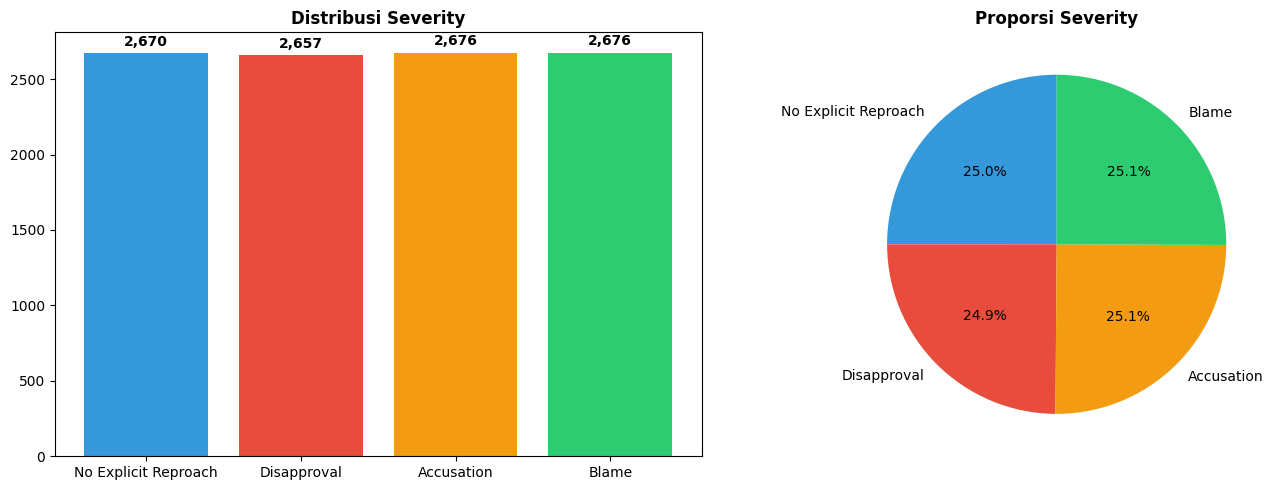

In [107]:
# Distribusi severity setelah preprocessing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = data['severity'].value_counts().sort_index()
colors = ['#3498db','#e74c3c','#f39c12','#2ecc71']

axes[0].bar([severity_names[i] for i in counts.index], counts.values, color=colors)
axes[0].set_title('Distribusi Severity', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=[severity_names[i] for i in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Severity', fontweight='bold')
plt.tight_layout(); plt.show()


In [108]:
# Statistik panjang teks bersih per severity
data['clean_len'] = data['clean_text'].apply(lambda x: len(x.split()))

stats = data.groupby('severity')['clean_len'].describe()
stats.index = [severity_names[i] for i in stats.index]
display(stats[['count','mean','min','max']].round(1))


,count,mean,min,max
No Explicit Reproach,2670.0,4.7,1.0,47.0
Disapproval,2657.0,5.8,1.0,61.0
Accusation,2676.0,20.2,1.0,77.0
Blame,2676.0,19.6,1.0,73.0


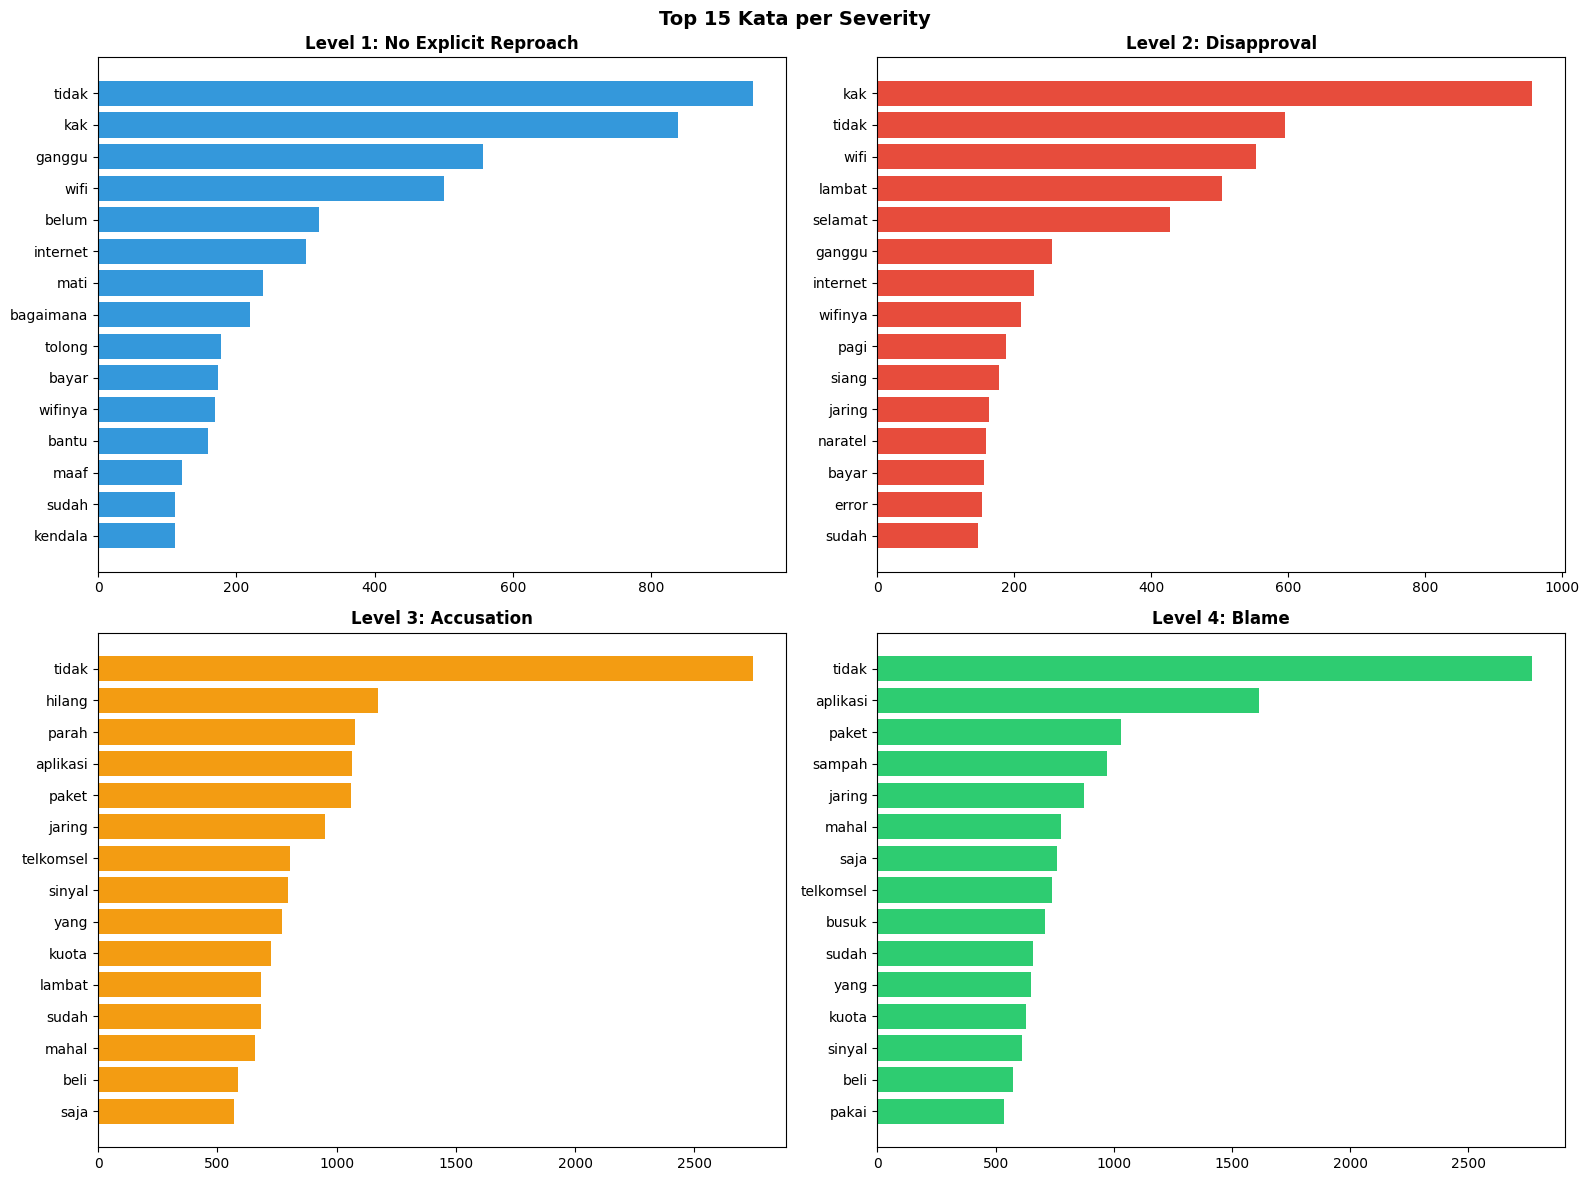

In [109]:
# Top 15 kata paling sering per severity (setelah preprocessing)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, (level, name) in enumerate(severity_names.items()):
    ax = axes[idx//2][idx%2]
    words = ' '.join(data[data['severity']==level]['clean_text']).split()
    from collections import Counter
    top = Counter(words).most_common(15)
    ax.barh([w[0] for w in top][::-1], [w[1] for w in top][::-1], color=colors[idx])
    ax.set_title(f'Level {level}: {name}', fontweight='bold')
plt.suptitle('Top 15 Kata per Severity', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()


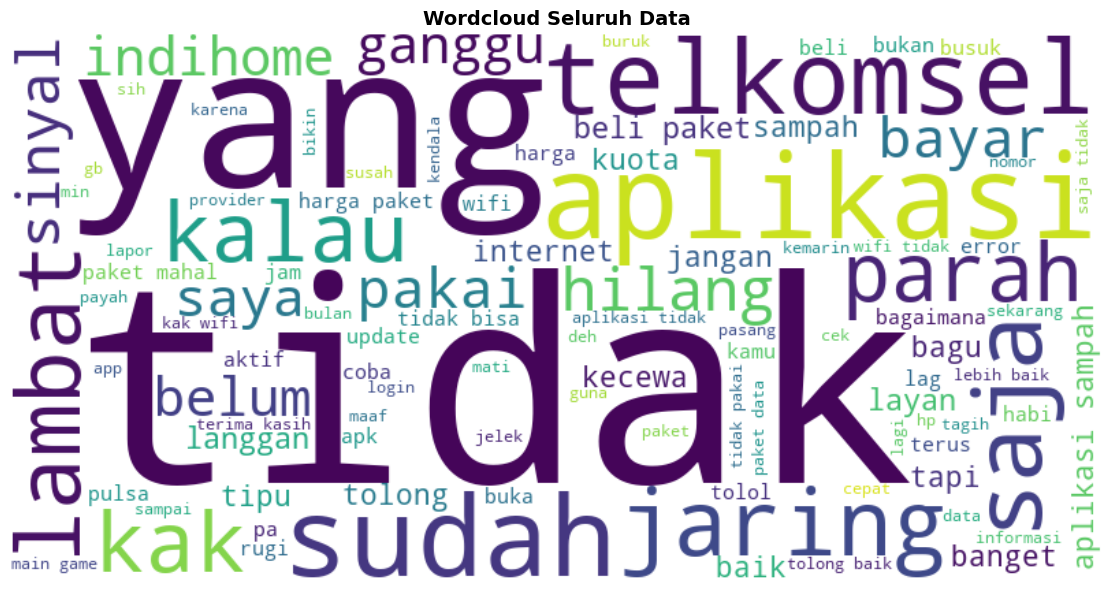

In [110]:
# Wordcloud untuk keseluruhan data yang telah diproses
all_words = ' '.join(data['clean_text'])
word_cloud = WordCloud(width=800, height=400, background_color='white',
                       colormap='viridis', max_words=100).generate(all_words)
plt.figure(figsize=(12, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.title('Wordcloud Seluruh Data', fontweight='bold', fontsize=14)
plt.axis('off'); plt.tight_layout(); plt.show()


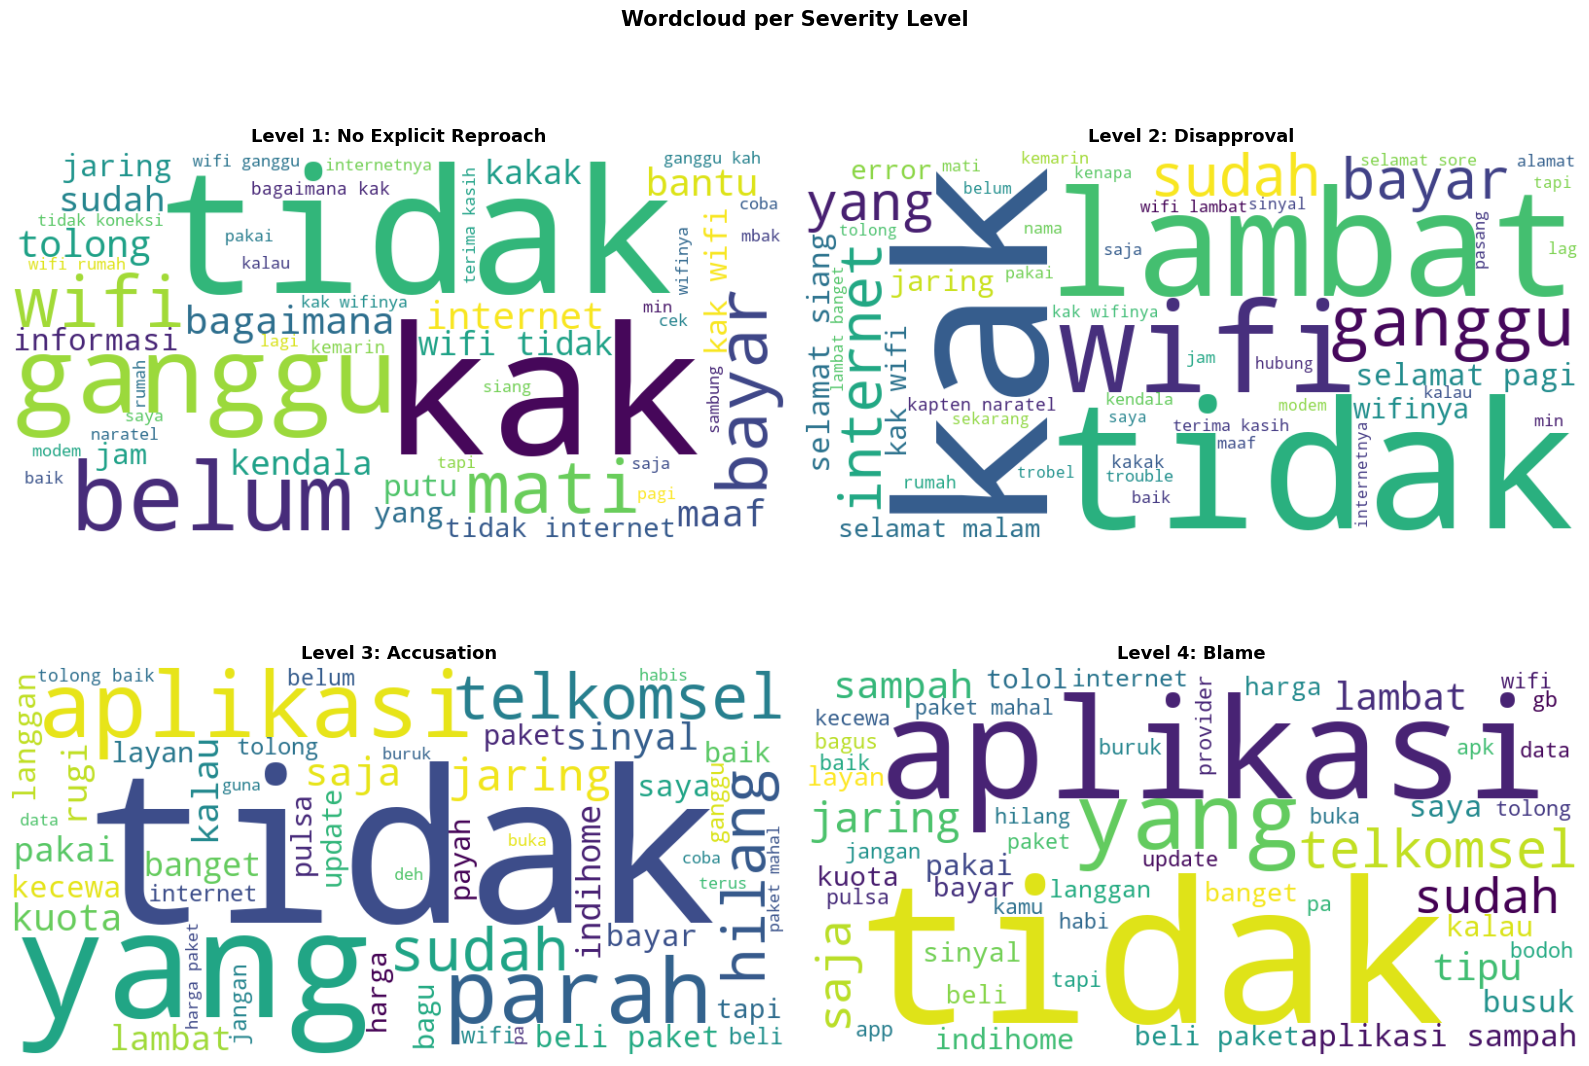

In [111]:
# Wordcloud per severity level
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, (level, name) in enumerate(severity_names.items()):
    ax = axes[idx//2][idx%2]
    text = ' '.join(data[data['severity']==level]['clean_text'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='viridis', max_words=50).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Level {level}: {name}', fontweight='bold', fontsize=13)
    ax.axis('off')
plt.suptitle('Wordcloud per Severity Level', fontweight='bold', fontsize=15)
plt.tight_layout(); plt.show()


# **5. FEATURE SELECTION / EXTRACTION**

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,2))
X = tfidf.fit_transform(data['clean_text'])
y = data['severity'].values
print(f'TF-IDF shape: {X.shape} (unigram + bigram, matriks sparse)')
print(f'Jumlah fitur: {len(tfidf.get_feature_names_out())}')


TF-IDF shape: (10679, 72041) (unigram + bigram, matriks sparse)
Jumlah fitur: 72041


In [ ]:
# 80% untuk training + validation (10-Fold CV), 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training + Validation (80%): {X_train.shape[0]:,}')
print(f'Testing (20%):               {X_test.shape[0]:,}')
print(f'Total:                       {X.shape[0]:,}')

Training + Validation (80%): 8,543
Testing (20%):               2,136
Total:                       10,679


## **EVALUASI**

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def evaluasi_model(model, nama):
    # === 10-Fold Cross Validation pada data TRAINING (80%) ===
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    prec = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision_macro')
    rec = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall_macro')
    f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
    
    # Tabel per fold
    df_fold = pd.DataFrame({
        'Fold': [f'Fold {i+1}' for i in range(10)] + ['Mean', 'Std'],
        'Accuracy': [f'{v:.4f}' for v in acc] + [f'{acc.mean():.4f}', f'{acc.std():.4f}'],
        'Precision': [f'{v:.4f}' for v in prec] + [f'{prec.mean():.4f}', f'{prec.std():.4f}'],
        'Recall': [f'{v:.4f}' for v in rec] + [f'{rec.mean():.4f}', f'{rec.std():.4f}'],
        'F1-Score': [f'{v:.4f}' for v in f1] + [f'{f1.mean():.4f}', f'{f1.std():.4f}'],
    })
    print(f'===== 10-FOLD CROSS VALIDATION (pada 80% data training): {nama} =====')
    display(df_fold)
    
    # Grafik akurasi per fold
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(1,11), acc*100, 'bo-', linewidth=2, label='Accuracy per Fold')
    ax.axhline(y=acc.mean()*100, color='orange', linestyle='--', label=f'Mean: {acc.mean():.2%}')
    ax.fill_between(range(1,11), (acc.mean()-acc.std())*100, (acc.mean()+acc.std())*100, alpha=0.15, color='blue')
    ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{nama} — Akurasi per Fold (10-Fold CV)', fontweight='bold')
    ax.set_xticks(range(1,11)); ax.legend(); plt.tight_layout(); plt.show()
    
    # === Hold-Out Test pada data TESTING (20%) ===
    model.fit(X_train, y_train)  # train pada 80%
    y_pred = model.predict(X_test)  # test pada 20% yang belum pernah dilihat
    
    print(f'\n===== HOLD-OUT TEST (pada 20% data testing): {nama} =====')
    display(pd.DataFrame([{
        'Accuracy': f'{accuracy_score(y_test, y_pred):.4f}',
        'Precision': f'{precision_score(y_test, y_pred, average="macro", zero_division=0):.4f}',
        'Recall': f'{recall_score(y_test, y_pred, average="macro", zero_division=0):.4f}',
        'F1-Score': f'{f1_score(y_test, y_pred, average="macro", zero_division=0):.4f}',
    }]))
    print(classification_report(y_test, y_pred,
          target_names=[severity_names[i] for i in sorted(np.unique(y))], zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[severity_names[i] for i in sorted(np.unique(y))],
                yticklabels=[severity_names[i] for i in sorted(np.unique(y))], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {nama}', fontweight='bold')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
    
    return model, y_pred, {'acc': accuracy_score(y_test, y_pred),
        'prec': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'rec': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'cv_acc': acc.mean(), 'cv_f1': f1.mean()}

print('Fungsi evaluasi siap.')
print(f'  10-Fold CV   -> pada X_train ({X_train.shape[0]:,} data)')
print(f'  Hold-Out Test -> pada X_test  ({X_test.shape[0]:,} data)')


Fungsi evaluasi siap.
  10-Fold CV   -> pada X_train (8,543 data)
  Hold-Out Test -> pada X_test  (2,136 data)


===== 10-FOLD CROSS VALIDATION (pada 80% data training): Multinomial NB (alpha=1.0 / Laplace) =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.7661,0.7668,0.7659,0.7635
1,Fold 2,0.8211,0.8217,0.8209,0.8192
2,Fold 3,0.8246,0.8331,0.8244,0.8229
3,Fold 4,0.8033,0.8046,0.8030,0.8018
4,Fold 5,0.7951,0.7971,0.7948,0.7937
5,Fold 6,0.7998,0.8036,0.7995,0.7984
6,Fold 7,0.8068,0.8083,0.8064,0.8048
7,Fold 8,0.8232,0.8254,0.8227,0.8208
8,Fold 9,0.8068,0.8059,0.8066,0.8050
9,Fold 10,0.7752,0.7786,0.7750,0.7695


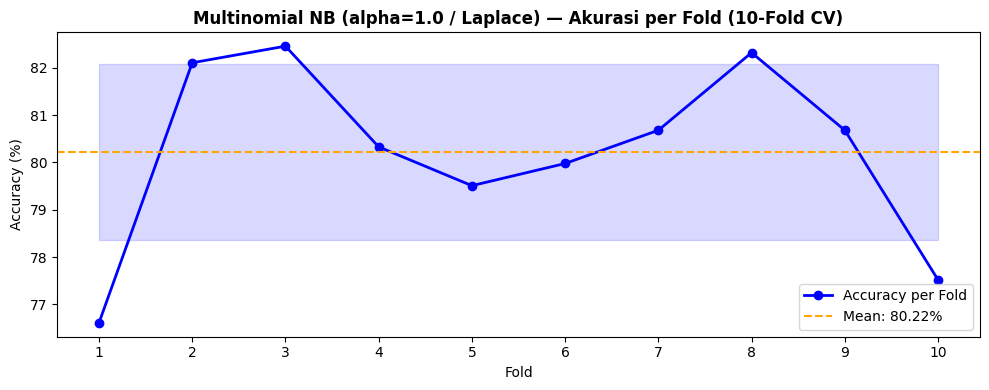


===== HOLD-OUT TEST (pada 20% data testing): Multinomial NB (alpha=1.0 / Laplace) =====


,Accuracy,Precision,Recall,F1-Score
0,0.8081,0.8091,0.8078,0.8044


                      precision    recall  f1-score   support

No Explicit Reproach       0.78      0.78      0.78       534
         Disapproval       0.81      0.64      0.72       532
          Accusation       0.78      0.92      0.84       535
               Blame       0.87      0.90      0.88       535

            accuracy                           0.81      2136
           macro avg       0.81      0.81      0.80      2136
        weighted avg       0.81      0.81      0.80      2136



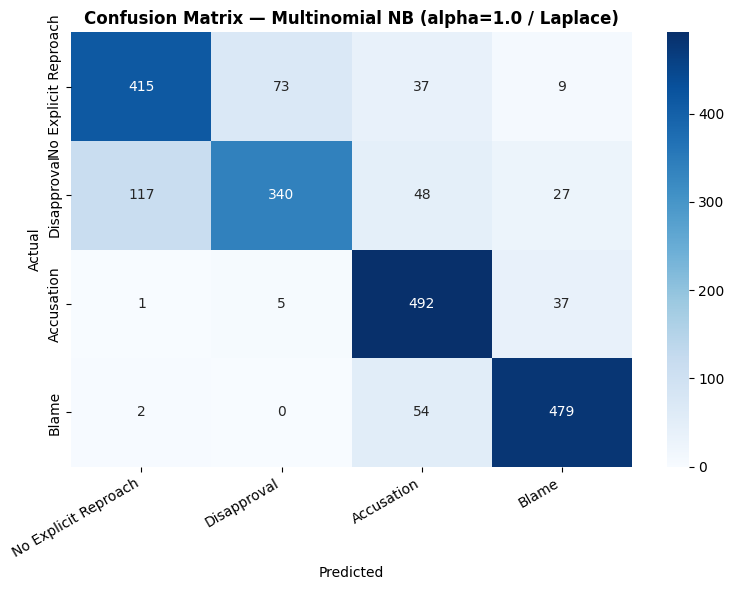

In [ ]:
# 3. Multinomial Naive Bayes (alpha = 1.0 / Laplace smoothing)
clf_nb, y_pred_nb, res_nb = evaluasi_model(
    MultinomialNB(alpha=1.0), 'Multinomial NB (alpha=1.0 / Laplace)')


===== 10-FOLD CROSS VALIDATION (pada 80% data training): Complement NB (alpha=1.0 / Laplace) =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.7731,0.7710,0.7729,0.7706
1,Fold 2,0.8117,0.8118,0.8115,0.8097
2,Fold 3,0.8421,0.8452,0.8419,0.8398
3,Fold 4,0.8068,0.8059,0.8065,0.8051
4,Fold 5,0.8126,0.8129,0.8123,0.8108
5,Fold 6,0.8126,0.8111,0.8124,0.8109
6,Fold 7,0.7986,0.7979,0.7981,0.7961
7,Fold 8,0.8220,0.8224,0.8216,0.8198
8,Fold 9,0.8033,0.8014,0.8031,0.8016
9,Fold 10,0.7822,0.7816,0.7820,0.7775


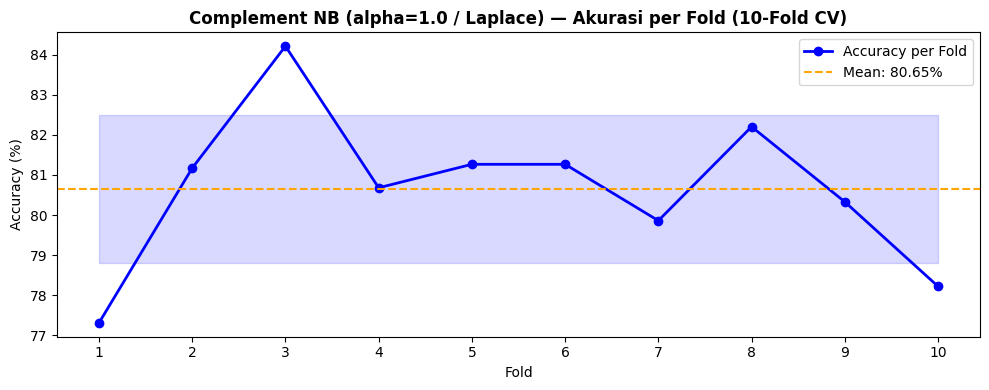


===== HOLD-OUT TEST (pada 20% data testing): Complement NB (alpha=1.0 / Laplace) =====


,Accuracy,Precision,Recall,F1-Score
0,0.8127,0.8104,0.8125,0.8094


                      precision    recall  f1-score   support

No Explicit Reproach       0.75      0.77      0.76       534
         Disapproval       0.78      0.65      0.71       532
          Accusation       0.84      0.90      0.87       535
               Blame       0.87      0.93      0.90       535

            accuracy                           0.81      2136
           macro avg       0.81      0.81      0.81      2136
        weighted avg       0.81      0.81      0.81      2136



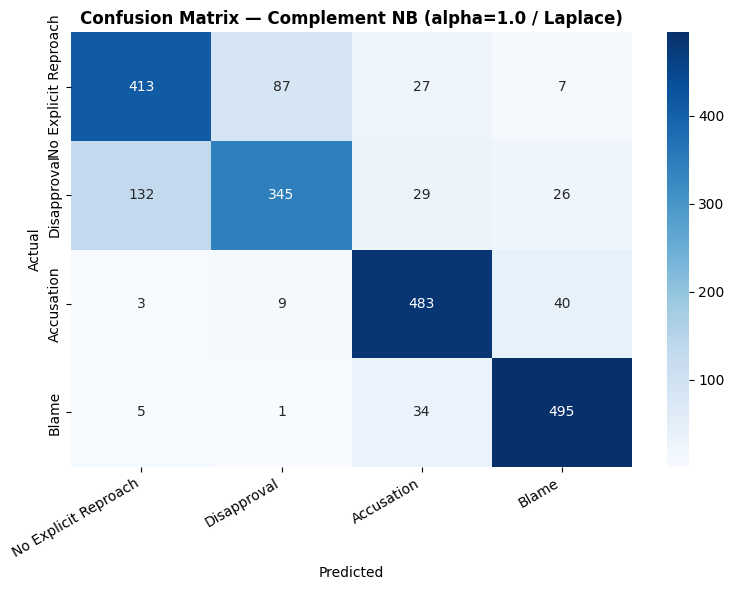

In [116]:
# 3b. Complement Naive Bayes (alpha = 1.0 / Laplace smoothing)
clf_cnb, y_pred_cnb, res_cnb = evaluasi_model(
    ComplementNB(alpha=1.0), 'Complement NB (alpha=1.0 / Laplace)')


## **KOMPARASI: Support Vector Machine (SVM)**

===== 10-FOLD CROSS VALIDATION (pada 80% data training): SVM Linear (C=2) =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.8596,0.8630,0.8595,0.8602
1,Fold 2,0.8795,0.8831,0.8794,0.8797
2,Fold 3,0.9029,0.9083,0.9028,0.9027
3,Fold 4,0.8770,0.8792,0.8769,0.8774
4,Fold 5,0.8536,0.8573,0.8533,0.8537
5,Fold 6,0.8829,0.8856,0.8827,0.8836
6,Fold 7,0.8934,0.8950,0.8933,0.8934
7,Fold 8,0.8817,0.8840,0.8813,0.8814
8,Fold 9,0.8665,0.8714,0.8664,0.8665
9,Fold 10,0.8560,0.8626,0.8558,0.8552


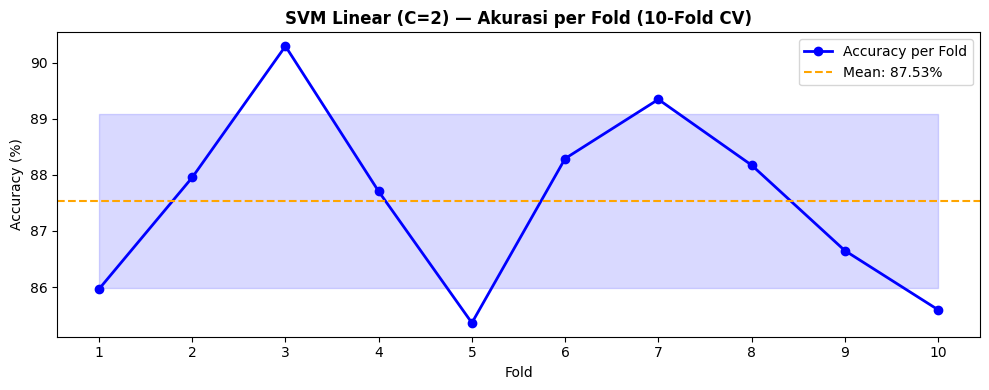


===== HOLD-OUT TEST (pada 20% data testing): SVM Linear (C=2) =====


,Accuracy,Precision,Recall,F1-Score
0,0.8750,0.8783,0.8748,0.8750


                      precision    recall  f1-score   support

No Explicit Reproach       0.77      0.87      0.81       534
         Disapproval       0.83      0.75      0.79       532
          Accusation       0.94      0.96      0.95       535
               Blame       0.98      0.92      0.95       535

            accuracy                           0.88      2136
           macro avg       0.88      0.87      0.87      2136
        weighted avg       0.88      0.88      0.88      2136



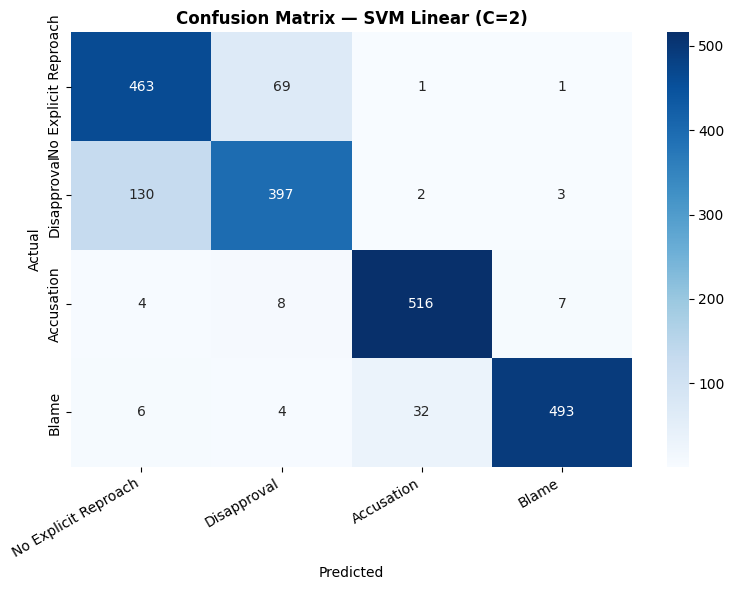

In [ ]:
# 4. SVM Linear Kernel (C=2)
clf_svm, y_pred_svm, res_svm = evaluasi_model(
    SVC(kernel='linear', C=2, random_state=42), 'SVM Linear (C=2)')


===== 10-FOLD CROSS VALIDATION (pada 80% data training): SVM Polynomial =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.6105,0.6817,0.6103,0.6045
1,Fold 2,0.6784,0.7435,0.6781,0.6752
2,Fold 3,0.6795,0.7702,0.6794,0.6861
3,Fold 4,0.6417,0.7320,0.6413,0.6459
4,Fold 5,0.6171,0.7000,0.6167,0.6189
5,Fold 6,0.6534,0.7319,0.6529,0.6548
6,Fold 7,0.6358,0.7352,0.6353,0.6390
7,Fold 8,0.6557,0.7291,0.6548,0.6543
8,Fold 9,0.6300,0.7099,0.6296,0.6305
9,Fold 10,0.6347,0.7135,0.6342,0.6318


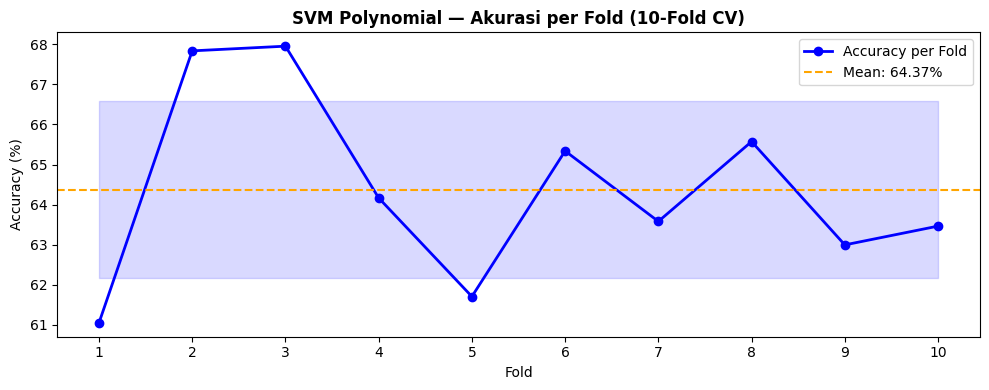


===== HOLD-OUT TEST (pada 20% data testing): SVM Polynomial =====


,Accuracy,Precision,Recall,F1-Score
0,0.6428,0.7140,0.6424,0.6389


                      precision    recall  f1-score   support

No Explicit Reproach       0.76      0.46      0.58       534
         Disapproval       0.76      0.44      0.56       532
          Accusation       0.48      0.94      0.63       535
               Blame       0.86      0.73      0.79       535

            accuracy                           0.64      2136
           macro avg       0.71      0.64      0.64      2136
        weighted avg       0.71      0.64      0.64      2136



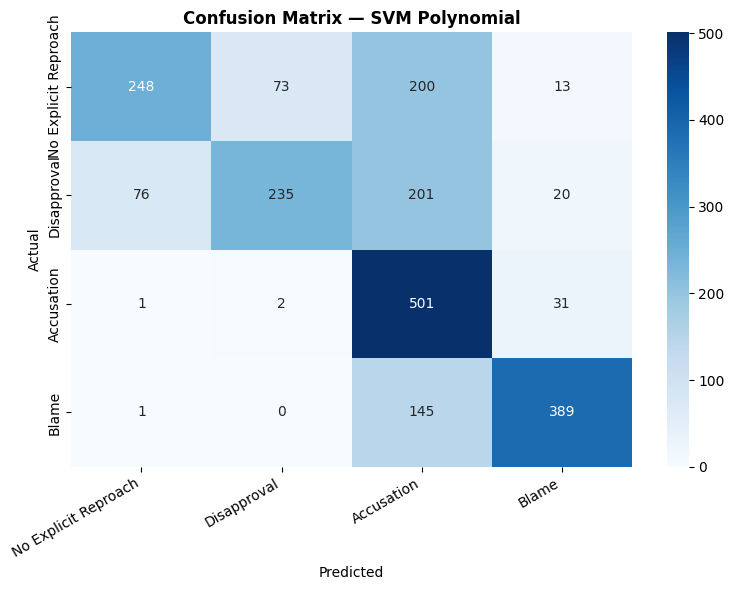

In [118]:
# 5. SVM Polynomial Kernel (C=2; degree pakai default pustaka)
clf_svm_poly, y_pred_svm_poly, res_poly = evaluasi_model(
    SVC(kernel='poly', C=2, random_state=42), 'SVM Polynomial')


===== 10-FOLD CROSS VALIDATION (pada 80% data training): SVM RBF =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.8398,0.8427,0.8397,0.8405
1,Fold 2,0.8784,0.8823,0.8782,0.8785
2,Fold 3,0.8819,0.8871,0.8817,0.8815
3,Fold 4,0.8806,0.8820,0.8804,0.8806
4,Fold 5,0.8489,0.8527,0.8487,0.8497
5,Fold 6,0.8806,0.8835,0.8804,0.8813
6,Fold 7,0.8841,0.8857,0.8839,0.8842
7,Fold 8,0.8700,0.8717,0.8696,0.8697
8,Fold 9,0.8607,0.8641,0.8605,0.8607
9,Fold 10,0.8525,0.8594,0.8523,0.8521


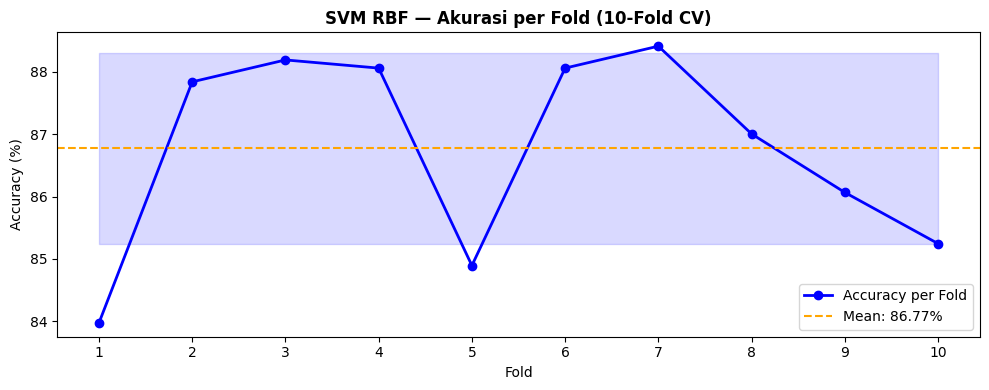


===== HOLD-OUT TEST (pada 20% data testing): SVM RBF =====


,Accuracy,Precision,Recall,F1-Score
0,0.8708,0.8734,0.8706,0.8709


                      precision    recall  f1-score   support

No Explicit Reproach       0.78      0.86      0.82       534
         Disapproval       0.82      0.76      0.79       532
          Accusation       0.93      0.96      0.94       535
               Blame       0.97      0.91      0.94       535

            accuracy                           0.87      2136
           macro avg       0.87      0.87      0.87      2136
        weighted avg       0.87      0.87      0.87      2136



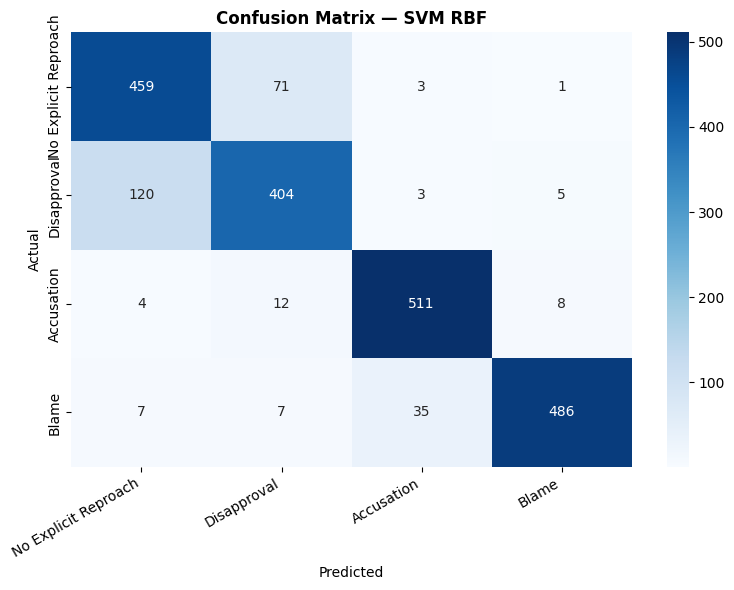

In [119]:
# 6. SVM RBF Kernel (C=2)
clf_svm_rbf, y_pred_svm_rbf, res_rbf = evaluasi_model(
    SVC(kernel='rbf', C=2, random_state=42), 'SVM RBF')


===== 10-FOLD CROSS VALIDATION (pada 80% data training): SVM Sigmoid =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.8608,0.8650,0.8607,0.8609
1,Fold 2,0.8749,0.8798,0.8747,0.8751
2,Fold 3,0.8924,0.8982,0.8922,0.8919
3,Fold 4,0.8829,0.8848,0.8827,0.8831
4,Fold 5,0.8630,0.8675,0.8627,0.8631
5,Fold 6,0.8841,0.8873,0.8839,0.8848
6,Fold 7,0.8876,0.8896,0.8874,0.8877
7,Fold 8,0.8735,0.8761,0.8731,0.8732
8,Fold 9,0.8653,0.8705,0.8652,0.8651
9,Fold 10,0.8548,0.8641,0.8546,0.8540


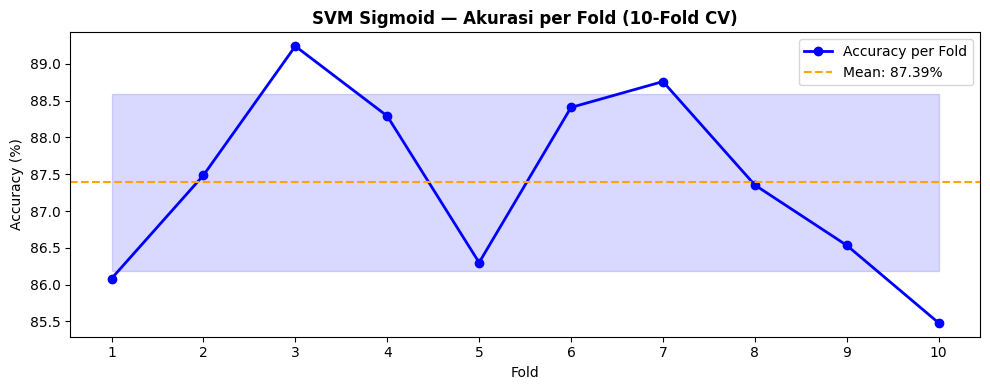


===== HOLD-OUT TEST (pada 20% data testing): SVM Sigmoid =====


,Accuracy,Precision,Recall,F1-Score
0,0.8717,0.8753,0.8715,0.8716


                      precision    recall  f1-score   support

No Explicit Reproach       0.76      0.87      0.81       534
         Disapproval       0.83      0.73      0.78       532
          Accusation       0.94      0.97      0.95       535
               Blame       0.98      0.92      0.95       535

            accuracy                           0.87      2136
           macro avg       0.88      0.87      0.87      2136
        weighted avg       0.88      0.87      0.87      2136



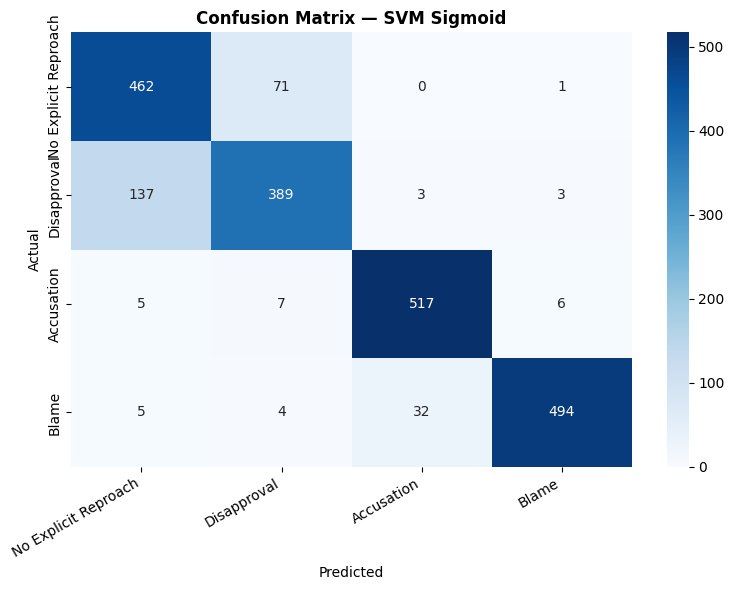

In [120]:
# 7. SVM Sigmoid Kernel (C=2)
clf_svm_sig, y_pred_svm_sig, res_sig = evaluasi_model(
    SVC(kernel='sigmoid', C=2, random_state=42), 'SVM Sigmoid')


## **PERBANDINGAN NAIVE BAYES vs SVM**

=== PERBANDINGAN SEMUA MODEL ===


,Model,10-Fold CV Acc,10-Fold CV F1,Hold-Out Acc,Precision,Recall,F1-Score
0,Multinomial NB,0.8022,0.7999,0.8081,0.8091,0.8078,0.8044
1,Complement NB,0.8065,0.8042,0.8127,0.8104,0.8125,0.8094
2,SVM Linear,0.8753,0.8754,0.8750,0.8783,0.8748,0.8750
3,SVM Poly,0.6437,0.6441,0.6428,0.7140,0.6424,0.6389
4,SVM RBF,0.8677,0.8679,0.8708,0.8734,0.8706,0.8709
5,SVM Sigmoid,0.8739,0.8739,0.8717,0.8753,0.8715,0.8716


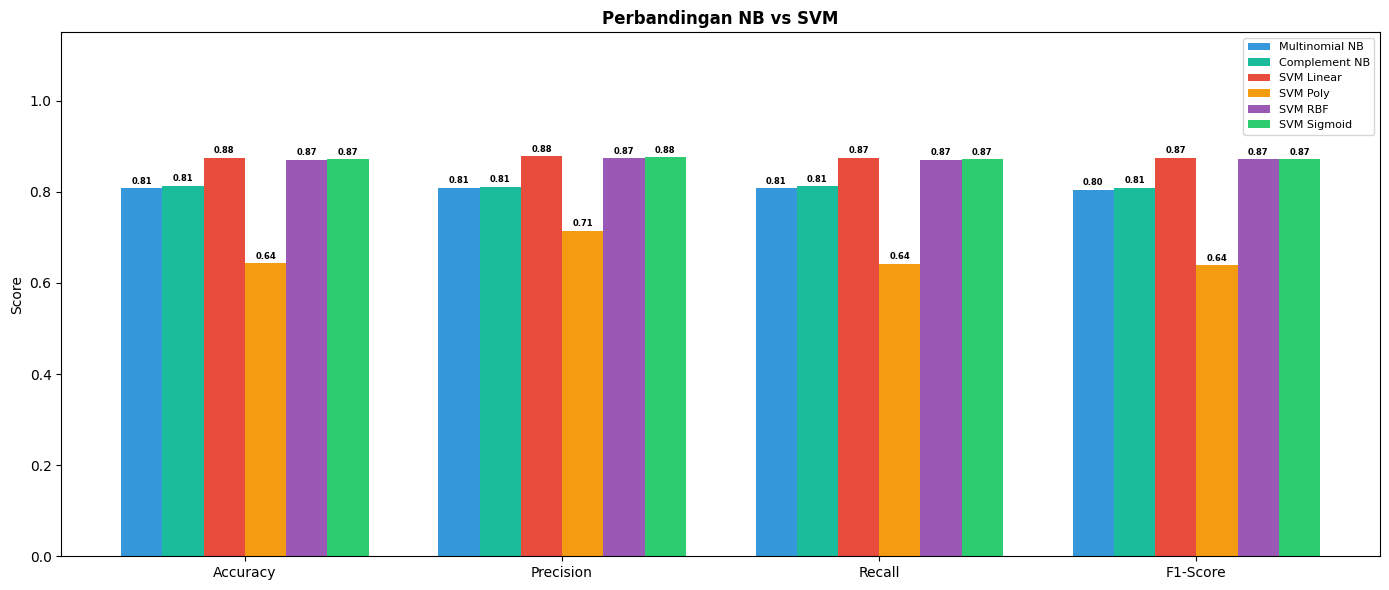

In [121]:
# Tabel Perbandingan Semua Model
all_results = {
    'Multinomial NB': res_nb, 'Complement NB': res_cnb,
    'SVM Linear': res_svm, 'SVM Poly': res_poly,
    'SVM RBF': res_rbf, 'SVM Sigmoid': res_sig
}

df_compare = pd.DataFrame([{
    'Model': name, '10-Fold CV Acc': f'{r["cv_acc"]:.4f}', '10-Fold CV F1': f'{r["cv_f1"]:.4f}',
    'Hold-Out Acc': f'{r["acc"]:.4f}', 'Precision': f'{r["prec"]:.4f}',
    'Recall': f'{r["rec"]:.4f}', 'F1-Score': f'{r["f1"]:.4f}'}
    for name, r in all_results.items()
])
print('=== PERBANDINGAN SEMUA MODEL ===')
display(df_compare)

# Visualisasi
models = list(all_results.keys())
metric_names = ['Accuracy','Precision','Recall','F1-Score']
clrs = ['#3498db','#1abc9c','#e74c3c','#f39c12','#9b59b6','#2ecc71']
x = np.arange(len(metric_names)); width = 0.13
fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(models):
    vals = [all_results[m]['acc'], all_results[m]['prec'], all_results[m]['rec'], all_results[m]['f1']]
    bars = ax.bar(x + (i-len(models)/2+0.5)*width, vals, width, label=m, color=clrs[i])
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=6, fontweight='bold')
ax.set_ylabel('Score'); ax.set_title('Perbandingan NB vs SVM', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_names); ax.legend(fontsize=8); ax.set_ylim(0,1.15)
plt.tight_layout(); plt.show()


# **TEST MODEL & EXPORT PKL**

In [122]:
# Test prediksi teks baru dengan model terbaik (SVM Linear)
test_texts = [
    'internet saya lambat sekali sudah 3 hari tidak diperbaiki',
    'kapan wifi saya diperbaiki? sudah lapor berkali kali',
    'ISP kalian penipu, saya mau berhenti langganan',
    'maling uang rakyat, saya laporkan ke polisi',
    'tolong cek tagihan saya bulan ini',
    'sinyal hilang terus di daerah saya, kecewa berat',
]

def preprocess_single(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join([cached_stem(w) for w in text.split()])

processed = [preprocess_single(t) for t in test_texts]
X_new = tfidf.transform(processed)
preds = clf_svm.predict(X_new)

display(pd.DataFrame({
    'Teks': test_texts,
    'Level': preds,
    'Severity': [severity_names.get(p, '?') for p in preds]
}))


,Teks,Level,Severity
0,internet saya lambat sekali sudah 3 hari tidak...,1,No Explicit Reproach
1,kapan wifi saya diperbaiki? sudah lapor berkal...,1,No Explicit Reproach
2,"ISP kalian penipu, saya mau berhenti langganan",4,Blame
3,"maling uang rakyat, saya laporkan ke polisi",4,Blame
4,tolong cek tagihan saya bulan ini,1,No Explicit Reproach
5,"sinyal hilang terus di daerah saya, kecewa berat",3,Accusation


In [123]:
# Export TF-IDF Vectorizer
os.makedirs('../model', exist_ok=True)
with open('../model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
size = os.path.getsize('../model/tfidf_vectorizer.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'tfidf_vectorizer.pkl', 'Ukuran': f'{size:.2f} MB', 'Keterangan': 'TF-IDF (unigram+bigram)'}]))


,File,Ukuran,Keterangan
0,tfidf_vectorizer.pkl,1.73 MB,TF-IDF (unigram+bigram)


In [124]:
# Export Multinomial Naive Bayes
with open('../model/multinomial_nb.pkl', 'wb') as f:
    pickle.dump(clf_nb, f)
size = os.path.getsize('../model/multinomial_nb.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'multinomial_nb.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'alpha=1.0 (Laplace)', 'Accuracy': f'{res_nb["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,multinomial_nb.pkl,4.40 MB,alpha=1.0 (Laplace),0.8081


In [125]:
# Export SVM Linear
with open('../model/svm_linear.pkl', 'wb') as f:
    pickle.dump(clf_svm, f)
size = os.path.getsize('../model/svm_linear.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_linear.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'C=2, kernel=linear', 'Accuracy': f'{res_svm["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_linear.pkl,2.14 MB,"C=2, kernel=linear",0.8750


In [126]:
# Export SVM Polynomial
with open('../model/svm_poly.pkl', 'wb') as f:
    pickle.dump(clf_svm_poly, f)
size = os.path.getsize('../model/svm_poly.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_poly.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'kernel=poly, C=2', 'Accuracy': f'{res_poly["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_poly.pkl,2.58 MB,"kernel=poly, C=2",0.6428


In [127]:
# Export SVM RBF
with open('../model/svm_rbf.pkl', 'wb') as f:
    pickle.dump(clf_svm_rbf, f)
size = os.path.getsize('../model/svm_rbf.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_rbf.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'kernel=rbf, C=2', 'Accuracy': f'{res_rbf["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_rbf.pkl,2.43 MB,"kernel=rbf, C=2",0.8708


In [128]:
# Export SVM Sigmoid
with open('../model/svm_sigmoid.pkl', 'wb') as f:
    pickle.dump(clf_svm_sig, f)
size = os.path.getsize('../model/svm_sigmoid.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_sigmoid.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'kernel=sigmoid, C=2', 'Accuracy': f'{res_sig["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_sigmoid.pkl,1.98 MB,"kernel=sigmoid, C=2",0.8717


# **OUTPUT NLP**

In [ ]:
# 1. Muat seluruh pesan customer asli (message, kode_user)
PESAN_PELANGGAN = '../dataset/data_pesan_customer.csv'  
df_cust = pd.read_csv(PESAN_PELANGGAN).dropna(subset=['message']).copy()

# 2. Terapkan PIPELINE PREPROCESSING YANG SAMA dengan data latih
df_cust = clean_text(df_cust, 'message', 'case_folding')                 # 1. cleaning
df_cust['case_folding'] = df_cust['case_folding'].str.lower()            # 2. case folding
df_cust['tok'] = df_cust['case_folding'].apply(word_tokenize)            # 3. tokenizing
df_cust['tok'] = df_cust['tok'].apply(                                   # 4. stopword removal
    lambda toks: [t for t in toks if t not in stopwords and len(t) > 1])
df_cust['tok'] = df_cust['tok'].apply(                                   # 5. normalisasi
    lambda toks: [norm_dict.get(t, t) for t in toks])
df_cust['tok'] = df_cust['tok'].apply(                                   # 6. stemming
    lambda toks: [cached_stem(t) for t in toks])
df_cust['clean_text'] = df_cust['tok'].apply(lambda x: ' '.join(x))
df_cust = df_cust[df_cust['clean_text'].str.strip() != ''].reset_index(drop=True)

# 3. Prediksi severity dengan model terbaik (SVM Linear)
df_cust['predicted_severity'] = clf_svm.predict(tfidf.transform(df_cust['clean_text']))

# 4. Pecah kode_user yang berisi >1 id (dipisah koma) agar setiap pelanggan terhitung
df_cust['kode_user'] = df_cust['kode_user'].astype(str).str.split(',')
df_cust = df_cust.explode('kode_user')
df_cust['kode_user'] = df_cust['kode_user'].str.strip()

# 5. Agregasi Maximum Severity per pelanggan (Jin & Aletras, 2021)
severity_per_user = df_cust.groupby('kode_user')['predicted_severity'].max().reset_index()
print('User unik:', len(severity_per_user))
display(severity_per_user['predicted_severity'].value_counts().sort_index().to_frame('Jumlah User'))

# 6. Simpan output
os.makedirs('../output', exist_ok=True)
df_cust[['message','clean_text','predicted_severity','kode_user']].to_csv('../output/data_with_severity.csv', index=False)
severity_per_user.to_csv('../output/severity_per_user.csv', index=False)
data.to_csv('../output/data_preprocessed.csv', index=False)
print('Output tersimpan: data_with_severity.csv, severity_per_user.csv, data_preprocessed.csv')

User unik: 7370


,Jumlah User
predicted_severity,
1,1097
2,5283
3,536
4,454


Output tersimpan: data_with_severity.csv, severity_per_user.csv, data_preprocessed.csv
